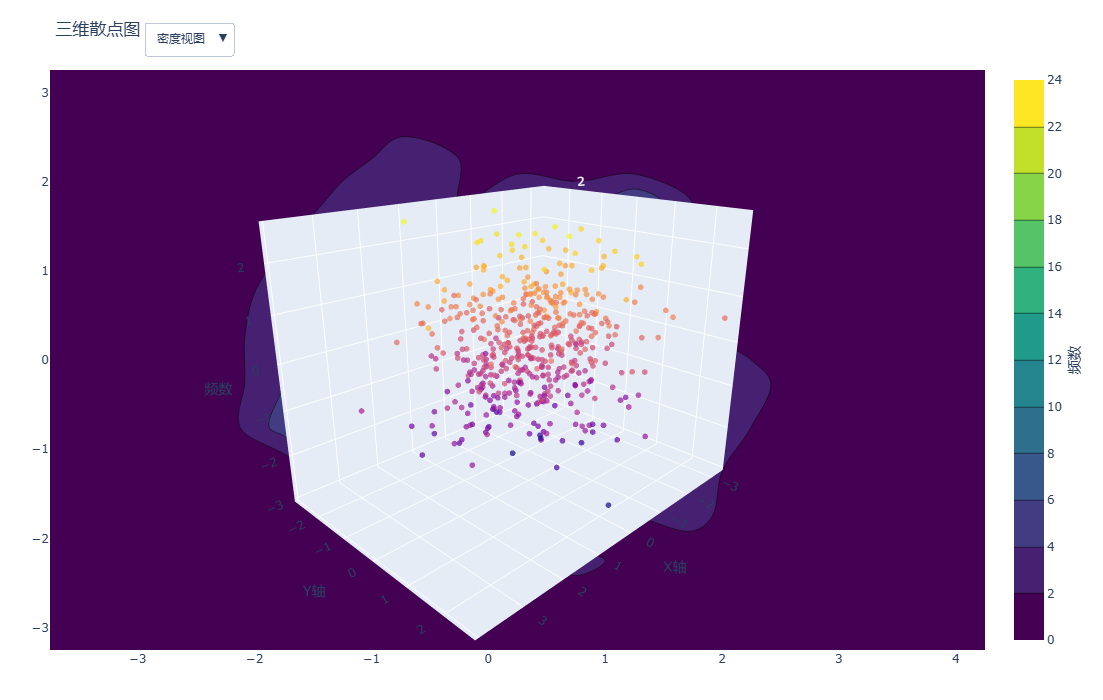

In [3]:
import plotly.graph_objects as go
import numpy as np

# 生成示例数据
x = np.random.randn(500)  # X轴数据
y = np.random.randn(500)  # Y轴数据
z = np.random.randn(500)  # Z轴数据

# 创建3D散点图
fig = go.Figure(data=[
    go.Histogram2dContour(
        x=x, y=y, z=z,
        histfunc="count",  # 计算频数
        colorscale='Viridis',
        contours=dict(
            showlabels=True,
            labelfont=dict(size=12, color='white')
        ),
        colorbar=dict(
            title='频数',
            titleside='right'
        )
    )
])

# 添加三维点
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=3,
        color=z,
        colorscale='Plasma',
        opacity=0.7
    ),
    name='数据点'
))

# 设置布局
fig.update_layout(
    title='三维散点图',
    scene=dict(
        xaxis=dict(title='X轴'),
        yaxis=dict(title='Y轴'),
        zaxis=dict(title='频数'),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.8)  # 视角调整
        )
    ),
    width=900,
    height=700,
    margin=dict(l=50, r=50, b=50, t=50)
)

# 添加下拉菜单（交互功能）
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    label="密度视图",
                    method="update",
                    args=[{"visible": [True, False]}]
                ),
                dict(
                    label="散点视图",
                    method="update",
                    args=[{"visible": [False, True]}]
                ),
                dict(
                    label="组合视图",
                    method="update",
                    args=[{"visible": [True, True]}]
                )
            ]),
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.1,
            yanchor="top"
        )
    ]
)

fig.show()

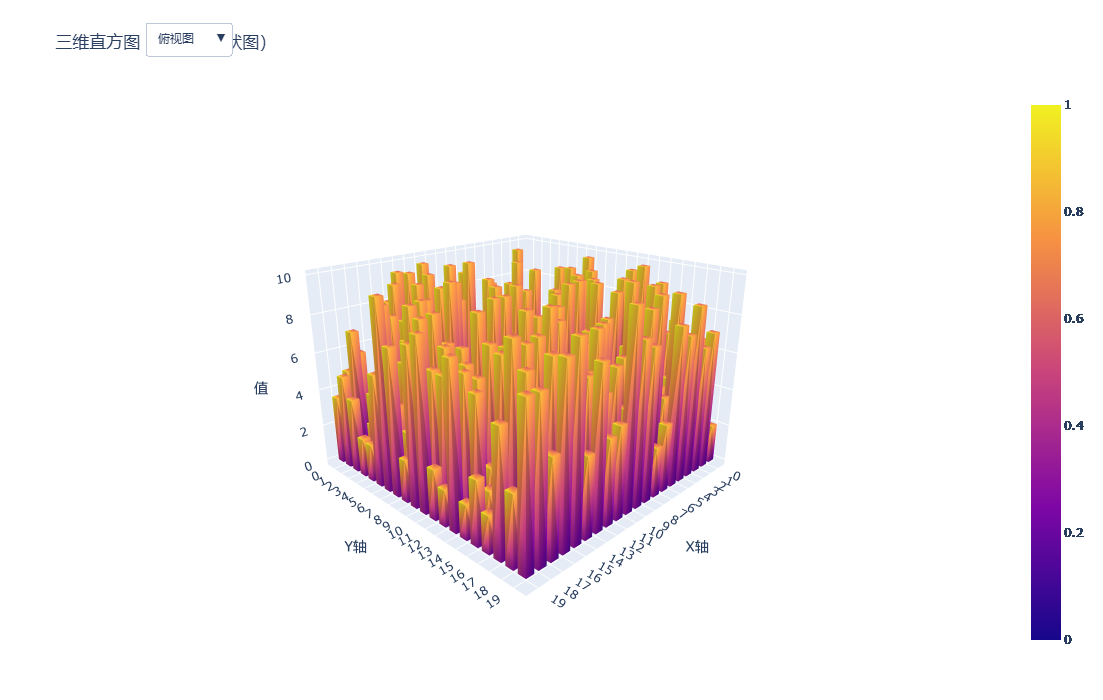

In [9]:
import plotly.graph_objects as go
import numpy as np

# 此图绘制比较耗时，请等待
# 设置随机种子保证可重复性
np.random.seed(42)

# 生成示例数据 - 20x20的柱状图
x_pos = np.arange(20)
y_pos = np.arange(20)
x, y = np.meshgrid(x_pos, y_pos)
x, y = x.flatten(), y.flatten()

# 为每个柱子生成随机高度（0-10之间）
z = np.random.uniform(1, 10, size=len(x))

# 柱子宽度和间隙设置
bar_width = 0.8  # 柱子宽度（0-1之间）
gap = 0.15       # 柱子间隙

# 创建颜色映射（想要不同的渐变颜色，从这里修改）
colorscale = [[0, '#16078B'], 
              [0.25, '#7E07A5'],
              [0.5, '#C9447B'],
              [0.75, '#F69242'],
              [1, '#F1F121']]

# 创建3D柱状图
fig = go.Figure()

for xi, yi, zi in zip(x, y, z):
    fig.add_trace(go.Mesh3d(
        # 定义立方体的8个顶点
        x=[xi-bar_width/2+gap/2, xi-bar_width/2+gap/2, xi+bar_width/2-gap/2, xi+bar_width/2-gap/2,
           xi-bar_width/2+gap/2, xi-bar_width/2+gap/2, xi+bar_width/2-gap/2, xi+bar_width/2-gap/2],
        y=[yi-bar_width/2+gap/2, yi+bar_width/2-gap/2, yi+bar_width/2-gap/2, yi-bar_width/2+gap/2,
           yi-bar_width/2+gap/2, yi+bar_width/2-gap/2, yi+bar_width/2-gap/2, yi-bar_width/2+gap/2],
        z=[0, 0, 0, 0, zi, zi, zi, zi],
        
        # 定义立方体的6个面（每个面由2个三角形组成）
        i=[7, 0, 0, 0, 4, 4, 6, 6, 4, 0, 3, 2],
        j=[3, 4, 1, 2, 5, 6, 5, 2, 0, 1, 6, 3],
        k=[0, 7, 2, 3, 6, 7, 1, 1, 5, 5, 7, 6],
        
        intensity=np.linspace(0, 1, 8),  # 颜色渐变
        colorscale=colorscale,
        showscale=True,
        name=f'({xi},{yi})'
    ))

# 设置布局
fig.update_layout(
    title='三维直方图（带间隙柱状图）',
    scene=dict(
        xaxis=dict(title='X轴', tickvals=x_pos),
        yaxis=dict(title='Y轴', tickvals=y_pos),
        zaxis=dict(title='值'),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=0.8)  # 调整视角
        ),
        aspectratio=dict(x=1, y=1, z=0.7)  # 调整比例
    ),
    width=900,
    height=700,
    margin=dict(l=50, r=50, b=50, t=50)
)

# 添加交互式按钮
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    label="俯视图",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=0, y=0, z=2.5)}]
                ),
                dict(
                    label="45°视角",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=1.5, y=1.5, z=0.8)}]
                ),
                dict(
                    label="侧视图",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=0, y=2.5, z=0)}]
                )
            ]),
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ]
)

fig.show()

In [8]:
pip install -U kaleido

   ---------------------------------------- 0.0/65.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/65.9 MB 5.6 MB/s eta 0:00:12
   - -------------------------------------- 1.8/65.9 MB 9.1 MB/s eta 0:00:08
   -- ------------------------------------- 4.5/65.9 MB 9.3 MB/s eta 0:00:07
   ---- ----------------------------------- 6.8/65.9 MB 10.0 MB/s eta 0:00:06
   ---- ----------------------------------- 8.1/65.9 MB 9.1 MB/s eta 0:00:07
   ------ --------------------------------- 10.7/65.9 MB 9.7 MB/s eta 0:00:06
   ------- -------------------------------- 11.8/65.9 MB 9.0 MB/s eta 0:00:07
   -------- ------------------------------- 13.9/65.9 MB 9.1 MB/s eta 0:00:06
   --------- ------------------------------ 15.7/65.9 MB 9.1 MB/s eta 0:00:06
   ---------- ----------------------------- 17.8/65.9 MB 9.1 MB/s eta 0:00:06
   ----------- ---------------------------- 19.7/65.9 MB 9.1 MB/s eta 0:00:06
   ------------- -------------------------- 21.5/65.9 MB 9.1 MB/s eta 0:00:0

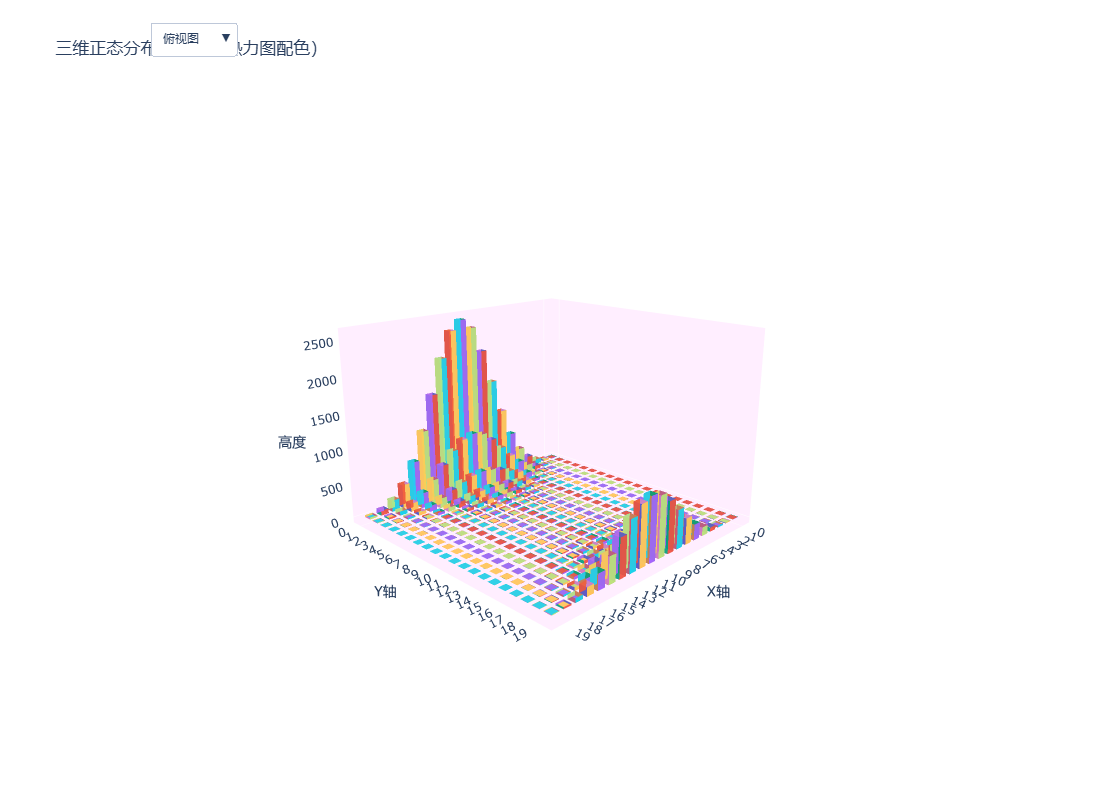

In [2]:
import plotly.graph_objects as go
import numpy as np

# 这个图的绘制，非常耗时，需要几分钟左右，请耐心等待，
# 设置随机种子保证可重复性
np.random.seed(42)

# 创建网格数据 (20x20)
x_pos = np.arange(20)
y_pos = np.arange(20)
x, y = np.meshgrid(x_pos, y_pos)
x, y = x.flatten(), y.flatten()

# 生成正态分布形状的高度数据
def gaussian_2d(x, y, mx=10, my=10, sx=3, sy=3):
    return 10 * np.exp(-((x-mx)**2/(2*sx**2) + -((y-my)**2/(2*sy**2))))

z = gaussian_2d(x, y)  # 应用正态分布函数

# 柱子宽度和间隙设置
bar_width = 0.8  # 柱子宽度（0-1之间）
gap = 0.15       # 柱子间隙

# 热力图配色方案 (从蓝到红)
colorscale = [
    [0.0, 'rgb(5,10,172)'],
    [0.25, 'rgb(40,60,190)'],
    [0.5, 'rgb(70,100,245)'],
    [0.75, 'rgb(90,120,245)'],
    [1.0, 'rgb(250,50,80)']
]

# 创建3D柱状图
fig = go.Figure()

for xi, yi, zi in zip(x, y, z):
    # 定义立方体的8个顶点坐标
    vertices = [
        [xi-bar_width/2+gap/2, yi-bar_width/2+gap/2, 0],  # 0: 底面左下
        [xi-bar_width/2+gap/2, yi+bar_width/2-gap/2, 0],  # 1: 底面右下
        [xi+bar_width/2-gap/2, yi+bar_width/2-gap/2, 0],  # 2: 底面右上
        [xi+bar_width/2-gap/2, yi-bar_width/2+gap/2, 0],  # 3: 底面左上
        [xi-bar_width/2+gap/2, yi-bar_width/2+gap/2, zi], # 4: 顶面左下
        [xi-bar_width/2+gap/2, yi+bar_width/2-gap/2, zi], # 5: 顶面右下
        [xi+bar_width/2-gap/2, yi+bar_width/2-gap/2, zi], # 6: 顶面右上
        [xi+bar_width/2-gap/2, yi-bar_width/2+gap/2, zi]  # 7: 顶面左上
    ]
    
    # 定义6个矩形面（每个面4个顶点）
    faces = [
        [0, 1, 2, 3],  # 底面
        [4, 5, 6, 7],  # 顶面
        [0, 1, 5, 4],  # 前面
        [1, 2, 6, 5],  # 右面
        [2, 3, 7, 6],  # 后面
        [3, 0, 4, 7]   # 左面
    ]
    
    # 为每个面添加单独的颜色（基于高度）
    for i, face in enumerate(faces):
        fig.add_trace(go.Mesh3d(
            x=[vertices[v][0] for v in face],
            y=[vertices[v][1] for v in face],
            z=[vertices[v][2] for v in face],
            
            # 定义面的连接方式（2个三角形组成矩形）
            i=[0, 0],
            j=[1, 2],
            k=[2, 3],
            
            color=zi,  # 颜色基于高度
            colorscale=colorscale,
            intensitymode='cell',
            showscale=True,
            opacity=0.9,
            name=f'({xi},{yi})' if i==0 else None  # 只显示一次图例
        ))

# 设置布局
fig.update_layout(
    title='三维正态分布直方图（热力图配色）',
    scene=dict(
        xaxis=dict(title='X轴', 
                   tickvals=x_pos,
                   showbackground=True,  # 显示背景平面
                   backgroundcolor="rgba(254, 212, 245, 0.9)",  # 浅粉色平面
                   # gridcolor="rgba(255,255,255,0.3)",  # 白色半透明网格线
                   showgrid=False,
                  ),
        yaxis=dict(title='Y轴', 
                   tickvals=y_pos,
                   showbackground=True,  # 显示背景平面
                   backgroundcolor="rgba(254, 212, 245, 0.9)",  # 浅粉色平面
                   # gridcolor="rgba(255,255,255,0.3)",  # 白色半透明网格线
                   showgrid=False, 
                  ),
        zaxis=dict(title='高度',
                   showbackground=True,  # 显示背景平面
                   backgroundcolor="rgba(254, 212, 245, 0.9)",  # 浅粉色平面
                   # gridcolor="rgba(255,255,255,0.3)",  # 白色半透明网格线
                   showgrid=False, 
                  ),
        camera=dict(
            eye=dict(x=1.8, y=1.8, z=0.8)  # 调整视角
        ),
        aspectratio=dict(x=1, y=1, z=0.7)  # 调整比例
    ),
    width=1000,
    height=800,
    margin=dict(l=50, r=50, b=50, t=50),
    coloraxis=dict(
        colorscale=colorscale,
        colorbar=dict(
            title='高度值',
            thickness=20,
            len=0.75
        )
    )
)

# 添加交互式按钮
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    label="俯视图",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=0, y=0, z=2.5)}]
                ),
                dict(
                    label="45°视角",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=1.8, y=1.8, z=0.8)}]
                ),
                dict(
                    label="侧视图",
                    method="update",
                    args=[{"scene.camera.eye": dict(x=0, y=2.5, z=0)}]
                )
            ]),
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ]
)
# fig.write_image("3d_histogram.png", scale=2)  # 2倍分辨率
fig.show()